In [2]:
import pandas as pd
import psycopg2
## Connect PostgreSQL Database
conn = psycopg2.connect(
    dbname="Financial_performance",
    user="postgres",
    password="2002",
    host="localhost",
    port="5432"
)

df = pd.read_sql("SELECT * FROM financial_summary LIMIT 10;", conn)
print(df.head())



   year  month business_unit  total_revenue  total_expense   net_profit
0  2023     12    Enterprise    18759926.35    -2210940.37  20970866.72
1  2023      8        Online    17956812.39    -2120417.36  20077229.75
2  2022      2        Online     6751487.05    -2030405.65   8781892.70
3  2022      2        Retail     8578837.28    -1691574.32  10270411.60
4  2023     11    Enterprise    17694082.19    -2038740.70  19732822.89


C:\Users\panda\AppData\Local\Temp\ipykernel_33012\4019116590.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM financial_summary LIMIT 10;", conn)


In [4]:
# Load SQL Data into Pandas
df = pd.read_sql("SELECT * FROM financial_summary;", conn)

C:\Users\panda\AppData\Local\Temp\ipykernel_33012\3025264558.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM financial_summary;", conn)


In [5]:
# Profit Margin Calculation

df["profit_margin"] = df["net_profit"] / df["total_revenue"]

In [6]:
df.head()

,year,month,business_unit,total_revenue,total_expense,net_profit,profit_margin
0,2023,12,Enterprise,18759926.35,-2210940.37,20970866.72,1.117854
1,2023,8,Online,17956812.39,-2120417.36,20077229.75,1.118084
2,2022,2,Online,6751487.05,-2030405.65,8781892.70,1.300735
3,2022,2,Retail,8578837.28,-1691574.32,10270411.60,1.197180
4,2023,11,Enterprise,17694082.19,-2038740.70,19732822.89,1.115222


In [7]:
# Yearly Financial Summary

yearly_summary = df.groupby("year").agg({
    "total_revenue": "sum",
    "total_expense": "sum",
    "net_profit": "sum"
})

print(yearly_summary)

      total_revenue  total_expense    net_profit
year                                            
2022   3.774261e+08   -83861309.16  4.612874e+08
2023   4.871825e+08   -83879990.64  5.710625e+08


In [8]:
# Rolling Profit Analysis
df = df.sort_values(["business_unit", "year", "month"])

df["rolling_profit"] = df.groupby("business_unit")["net_profit"].transform(
    lambda x: x.rolling(3).mean()
)
df

,year,month,business_unit,total_revenue,total_expense,net_profit,profit_margin,rolling_profit
31,2022,1,Enterprise,9000016.39,-2257337.53,11257353.92,1.250815,NaN
69,2022,2,Enterprise,7457335.63,-2406861.49,9864197.12,1.322751,NaN
66,2022,3,Enterprise,8314923.47,-1462616.33,9777539.80,1.175903,1.029970e+07
23,2022,4,Enterprise,10704597.61,-2324591.98,13029189.59,1.217158,1.089031e+07
51,2022,5,Enterprise,6565474.42,-2320340.92,8885815.34,1.353416,1.056418e+07
...,...,...,...,...,...,...,...,...
68,2023,8,Retail,16387964.54,-2441740.93,18829705.47,1.148996,1.560080e+07
65,2023,9,Retail,17408774.00,-2041040.66,19449814.66,1.117242,1.729515e+07
11,2023,10,Retail,12255166.37,-2154238.09,14409404.46,1.175782,1.756297e+07
47,2023,11,Retail,14328032.25,-2670788.52,16998820.77,1.186403,1.695268e+07


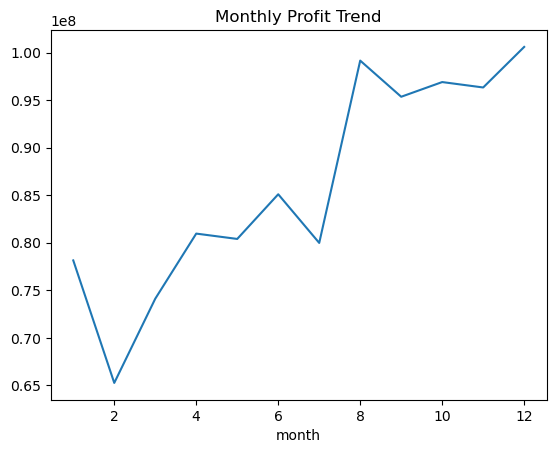

In [9]:
import matplotlib.pyplot as plt
# Monthly Profit Trend
df.groupby("month")["net_profit"].sum().plot()
plt.title("Monthly Profit Trend")
plt.show()

In [10]:
# Data Validation
print(df.shape)
print(df.columns)
print(df.dtypes)

df = df.sort_values(["business_unit", "year", "month"])

df["rolling_profit"] = df.groupby("business_unit")["net_profit"].transform(
    lambda x: x.rolling(3).mean()
)

print(df[["business_unit","year","month","net_profit","rolling_profit"]].head(10))

(72, 8)
Index(['year', 'month', 'business_unit', 'total_revenue', 'total_expense',
       'net_profit', 'profit_margin', 'rolling_profit'],
      dtype='object')
year                int64
month               int64
business_unit      object
total_revenue     float64
total_expense     float64
net_profit        float64
profit_margin     float64
rolling_profit    float64
dtype: object
   business_unit  year  month   net_profit  rolling_profit
31    Enterprise  2022      1  11257353.92             NaN
69    Enterprise  2022      2   9864197.12             NaN
66    Enterprise  2022      3   9777539.80    1.029970e+07
23    Enterprise  2022      4  13029189.59    1.089031e+07
51    Enterprise  2022      5   8885815.34    1.056418e+07
45    Enterprise  2022      6  13931109.93    1.194870e+07
52    Enterprise  2022      7  12796571.56    1.187117e+07
10    Enterprise  2022      8  12997924.58    1.324187e+07
60    Enterprise  2022      9  12781670.21    1.285872e+07
9     Enterprise  2022    